# Thesis Experiment: RL-Based Gamma Controller (Weekly Rebalancing)
**Setup:** 7-Day Rebalancing Frequency for realistic portfolio management.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from scipy.optimize import minimize
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded.")

Libraries loaded.


## Phase 1: Data Preparation

In [2]:
file_old = 'crypto_data_real.xlsx'
file_2024 = 'crypto_data_2024.xlsx'

def load_and_preprocess(f1, f2):
    r_old = pd.read_excel(f1, sheet_name='Returns', index_col=0)
    r_2024 = pd.read_excel(f2, sheet_name='Returns', index_col=0)
    r_old.index = pd.to_datetime(r_old.index)
    r_2024.index = pd.to_datetime(r_2024.index)
    assets = list(set(r_old.columns) & set(r_2024.columns))
    assets.sort()
    return r_old[assets], r_2024[assets], assets

ret_old, ret_2024, assets = load_and_preprocess(file_old, file_2024)
print(f"Data loaded. Assets: {len(assets)}")

Data loaded. Assets: 10


## Phase 2: Core Functions

In [3]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    eigenvalues[eigenvalues < lambda_max] = np.mean(eigenvalues[eigenvalues < lambda_max])
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised

def get_centrality_weights(returns_window, gamma=1.0):
    """
    Computes Network-Regularized Markowitz weights.
    Minimizes: w' * Sigma * w + gamma * (centrality' * w)
    Subject to: sum(w) = 1, w >= 0
    """
    T, N = returns_window.shape
    mu = returns_window.mean().values
    sigma = returns_window.std().values
    
    # 1. Denoised Covariance Matrix (RMT)
    corr_f = apply_rmt_filter(returns_window)
    cov_f = np.outer(sigma, sigma) * corr_f
    cov_f += np.eye(N) * 1e-8 # Numerical stability
    
    # 2. Centrality calculation
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    adj = np.maximum(0, 1 - dist_mat)
    G = nx.from_numpy_array(adj)
    try:
        centrality = nx.eigenvector_centrality(G, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(G).values()))

    # 3. Optimization
    # Objective: Risk + gamma * Centrality (treating high centrality as a 'cost' to diversify)
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bnds = tuple((0, 1) for _ in range(N))
    x0 = np.ones(N) / N
    
    res = minimize(fun, x0, method='SLSQP', bounds=bnds, constraints=cons)
    
    if not res.success:
        return np.ones(N) / N
        
    return res.x

class PortfolioStrategy:
    def __init__(self, name): 
        self.name = name
        self.last_gamma = 1.0
    def compute_weights(self, returns_window): raise NotImplementedError()
    
class EquallyWeighted(PortfolioStrategy):
    def compute_weights(self, returns_window): return np.ones(returns_window.shape[1])/returns_window.shape[1]
class ClassicalMarkowitz(PortfolioStrategy):
    def compute_weights(self, returns_window):
        cov = returns_window.cov().values
        inv_cov = np.linalg.pinv(cov)
        w = np.clip(inv_cov @ np.ones(cov.shape[0]), 0, 1)
        return w / np.sum(w)
class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name, gamma=1.0):
        super().__init__(name)
        self.gamma = gamma
    def compute_weights(self, returns_window): return get_centrality_weights(returns_window, self.gamma)

## Phase 3: RL Agent

In [4]:
class GammaPortfolioEnv(gym.Env):
    def __init__(self, returns_data, window_size=120, reward_mode='sharpe'):
        super().__init__()
        self.data = returns_data
        self.window_size = window_size
        self.reward_mode = reward_mode
        self.current_step = window_size
        self.action_space = spaces.Box(low=-10.0, high=10.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(4,), dtype=np.float32)
        self.port_val = 1.0
        self.peak_val = 1.0
        
    def _get_obs(self):
        win = self.data.iloc[self.current_step - self.window_size : self.current_step]
        # FEATURE SCALING: Multiply small values to improve PPO gradient stability
        m = win.mean().mean() * 100
        s = win.std().mean() * 100
        c = win.corr().values.mean()
        st_c = np.std(get_centrality_weights(win)) * 10
        return np.array([m, s, c, st_c], dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val = 1.0
        self.peak_val = 1.0
        return self._get_obs(), {}
        
    def step(self, action):
        win = self.data.iloc[self.current_step - self.window_size : self.current_step]
        w = get_centrality_weights(win, float(action[0]))
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        
        self.port_val *= (1 + port_ret)
        self.peak_val = max(self.peak_val, self.port_val)
        drawdown = (self.port_val - self.peak_val) / self.peak_val
        ew_ret = self.data.iloc[self.current_step].mean()
        
        if self.reward_mode == 'raw_return': reward = port_ret
        elif self.reward_mode == 'excess_return': reward = port_ret - ew_ret
        elif self.reward_mode == 'defensive': reward = port_ret - 2.0 * abs(drawdown)
        else: reward = port_ret / (win.values.std() + 1e-6)
            
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        return self._get_obs(), reward, done, False, {}

class RLNetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name, model_path):
        super().__init__(name)
        self.model = PPO.load(model_path)
    def compute_weights(self, returns_window):
        # MUST USE SAME SCALING AS IN ENV
        m = returns_window.mean().mean() * 100
        s = returns_window.std().mean() * 100
        c = returns_window.corr().values.mean()
        st_c = np.std(get_centrality_weights(returns_window)) * 10
        obs = np.array([m, s, c, st_c], dtype=np.float32)
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(action[0])
        return get_centrality_weights(returns_window, gamma=self.last_gamma)

## Phase 4: Backtest Engine (Fixed Frequency Rebalancing)

In [5]:
def run_backtest_with_frequency(strategy, data, window=120, rebalance_freq=7):
    rets = []
    dates = []
    weights_history = []
    gamma_history = []
    
    current_weights = None
    current_gamma = 1.0
    
    print(f"Processing {strategy.name} (Freq: {rebalance_freq} days)...")
    for i in range(window, len(data)):
        # REBALANCE ONLY EVERY 'rebalance_freq' DAYS
        if (i - window) % rebalance_freq == 0:
            window_df = data.iloc[i-window : i]
            current_weights = strategy.compute_weights(window_df)
            current_gamma = getattr(strategy, 'last_gamma', 1.0)
        
        # DAILY RETURN CALCULATION
        r = np.dot(current_weights, data.iloc[i].values)
        rets.append(r)
        dates.append(data.index[i])
        weights_history.append(current_weights)
        gamma_history.append(current_gamma)
        
    return pd.Series(rets, index=dates), pd.DataFrame(weights_history, index=dates, columns=data.columns), pd.Series(gamma_history, index=dates)

def calculate_metrics(r):
    cr = (1+r).cumprod()
    sharpe = (np.mean(r)/np.std(r))*np.sqrt(252)
    mdd = ((cr/cr.expanding().max())-1).min()
    return {"Total Return": f"{cr.iloc[-1]-1:.2%}", "Sharpe": f"{sharpe:.2f}", "MDD": f"{mdd:.2%}"}

## Phase 5: Comparative Analysis (7-Day Rebalancing)

Training RL models (50,000 steps)...


RL-Net (Sharpe):   0%|          | 0/50000 [00:00<?, ?it/s]

RL-Net (Defensive):   0%|          | 0/50000 [00:00<?, ?it/s]

RL-Net (Excess):   0%|          | 0/50000 [00:00<?, ?it/s]

Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing NW (Gamma=0.5) (Freq: 7 days)...
Processing EW ($1/N$) (Freq: 7 days)...
Processing Markowitz (MVP) (Freq: 7 days)...
Processing RL-Net (Sharpe) (Freq: 7 days)...
Processing RL-Net (Defensive) (Freq: 7 days)...
Processing RL-Net (Alpha/Excess) (Freq: 7 days)...


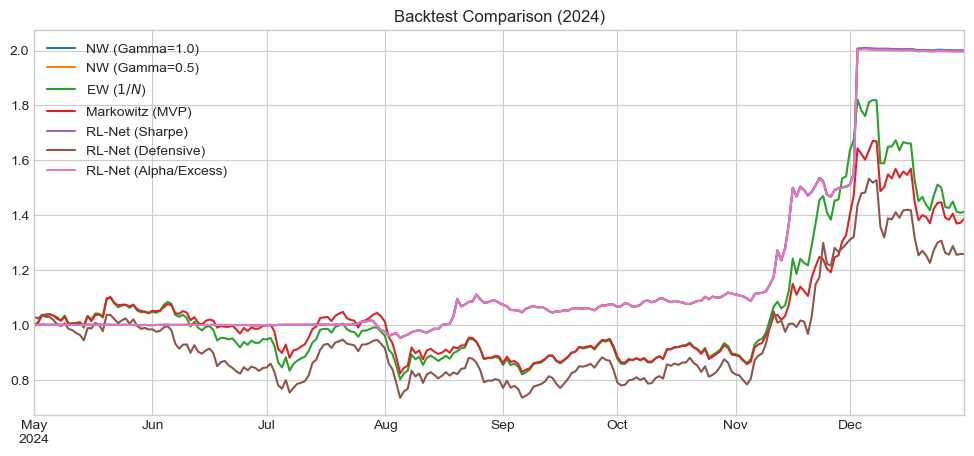

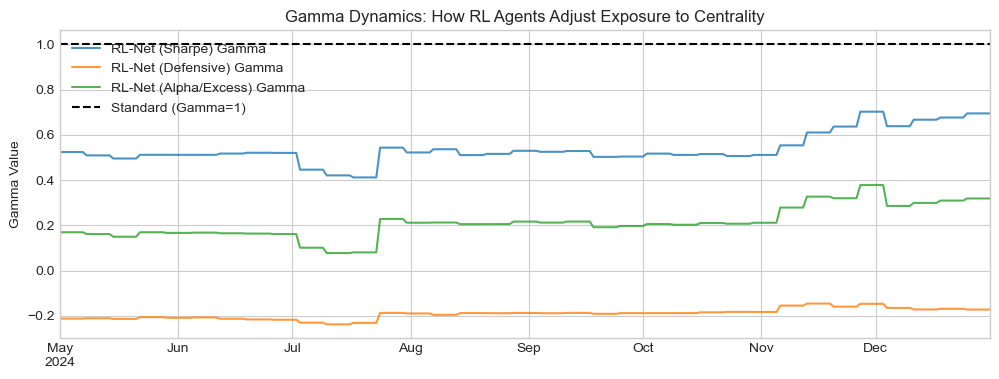

Saved: backtest_results/cumulative_returns.csv
Saved: backtest_results/daily_returns.csv
Saved: backtest_results/gamma_dynamics.csv
Saved: backtest_results/performance_metrics.csv
                      Total Return Sharpe      MDD
Strategy                                          
NW (Gamma=1.0)             100.07%   2.17   -6.40%
NW (Gamma=0.5)              99.83%   2.17   -6.39%
EW ($1/N$)                  41.30%   1.06  -27.04%
Markowitz (MVP)             38.77%   1.06  -25.23%
RL-Net (Sharpe)             99.91%   2.17   -6.39%
RL-Net (Defensive)          25.83%   0.74  -29.16%
RL-Net (Alpha/Excess)       99.59%   2.17   -6.38%


In [6]:
from tqdm.notebook import tqdm
from stable_baselines3.common.callbacks import BaseCallback

# === Custom Progress Bar Callback ===
class TqdmCallback(BaseCallback):
    def __init__(self, total_timesteps, desc='Training'):
        super().__init__()
        self.pbar = None
        self.total_timesteps = total_timesteps
        self.desc = desc

    def _on_training_start(self):
        self.pbar = tqdm(total=self.total_timesteps, desc=self.desc)

    def _on_step(self):
        self.pbar.update(1)
        return True

    def _on_training_end(self):
        if self.pbar:
            self.pbar.close()

# === Fungsi Training yang Dioptimasi ===
SET_WINDOW = 120
SET_REBALANCE = 7
STEPS = 50000

train_data = ret_old.iloc[:int(len(ret_old)*0.8)]

def train_optimized_model(env, name, desc='Training'):
    model = PPO(
        "MlpPolicy", 
        env, 
        learning_rate=0.0001,
        n_steps=2048,
        batch_size=64, 
        ent_coef=0.01,
        verbose=0
    )
    model.learn(total_timesteps=STEPS, callback=TqdmCallback(STEPS, desc=desc))
    model.save(name)
    return model

print(f"Training RL models ({STEPS:,} steps)...")
model_sharpe   = train_optimized_model(GammaPortfolioEnv(train_data, reward_mode='sharpe'),        'final_sharpe',  'RL-Net (Sharpe)')
model_defensive= train_optimized_model(GammaPortfolioEnv(train_data, reward_mode='defensive'),     'final_mdd',     'RL-Net (Defensive)')
model_alpha    = train_optimized_model(GammaPortfolioEnv(train_data, reward_mode='excess_return'), 'final_excess',  'RL-Net (Excess)')

# === Backtest Semua Strategi ===
strategies = [
    NetworkMarkowitz("NW (Gamma=1.0)", gamma=1.0),
    NetworkMarkowitz("NW (Gamma=0.5)", gamma=0.5),
    EquallyWeighted("EW ($1/N$)"), 
    ClassicalMarkowitz("Markowitz (MVP)"), 
    RLNetworkMarkowitz("RL-Net (Sharpe)",        "final_sharpe"),
    RLNetworkMarkowitz("RL-Net (Defensive)",     "final_mdd"),
    RLNetworkMarkowitz("RL-Net (Alpha/Excess)",  "final_excess")
]

results_map = {}
gamma_map = {}
for s in strategies:
    res, _, g_hist = run_backtest_with_frequency(s, ret_2024, window=SET_WINDOW, rebalance_freq=SET_REBALANCE)
    results_map[s.name] = res
    if "RL-Net" in s.name:
        gamma_map[s.name] = g_hist

# === Plot 1: Performa Portfolio ===
plt.figure(figsize=(12, 5))
for name, r in results_map.items():
    (1+r).cumprod().plot(label=name)
plt.title("Backtest Comparison (2024)")
plt.legend()
plt.show()

# === Plot 2: Gamma Dynamics RL ===
plt.figure(figsize=(12, 4))
for name, g in gamma_map.items():
    g.plot(label=f"{name} Gamma", alpha=0.8)
plt.axhline(1.0, color='black', linestyle='--', label="Standard (Gamma=1)")
plt.title("Gamma Dynamics: How RL Agents Adjust Exposure to Centrality")
plt.ylabel("Gamma Value")
plt.legend()
plt.show()

# === Tabel Metrik ===
stats = pd.DataFrame({name: calculate_metrics(r) for name, r in results_map.items()}).T

# === Simpan Data ke CSV ===
import os
csv_dir = 'backtest_results'
os.makedirs(csv_dir, exist_ok=True)

# 1. Cumulative Returns per strategi
cumret_df = pd.DataFrame({
    name: (1 + r).cumprod() for name, r in results_map.items()
})
cumret_df.index.name = 'Date'
cumret_df.to_csv(os.path.join(csv_dir, 'cumulative_returns.csv'))
print(f'Saved: {csv_dir}/cumulative_returns.csv')

# 2. Daily Returns per strategi
dailyret_df = pd.DataFrame(results_map)
dailyret_df.index.name = 'Date'
dailyret_df.to_csv(os.path.join(csv_dir, 'daily_returns.csv'))
print(f'Saved: {csv_dir}/daily_returns.csv')

# 3. Gamma Dynamics RL agents
if gamma_map:
    gamma_df = pd.DataFrame(gamma_map)
    gamma_df.index.name = 'Date'
    gamma_df.to_csv(os.path.join(csv_dir, 'gamma_dynamics.csv'))
    print(f'Saved: {csv_dir}/gamma_dynamics.csv')

# 4. Performance Metrics
stats_df = pd.DataFrame({name: calculate_metrics(r) for name, r in results_map.items()}).T
stats_df.index.name = 'Strategy'
stats_df.to_csv(os.path.join(csv_dir, 'performance_metrics.csv'))
print(f'Saved: {csv_dir}/performance_metrics.csv')
print(stats_df.to_string())
